In [1]:
# %%
from mpi4py import MPI
import psutil
import numpy as np
import random as rd
import pickle
import sympy
import copy
import gc
from datetime import datetime

from scipy import sparse
from qiskit_nature.second_q.hamiltonians.lattices import (
    BoundaryCondition,
    Lattice,
    LineLattice,
    SquareLattice
)
from qiskit.quantum_info import SparsePauliOp
from qiskit_nature.second_q.mappers import LogarithmicMapper
from qiskit_nature.second_q.hamiltonians import HeisenbergModel, QuadraticHamiltonian
from qiskit_nature.second_q.circuit.library import BogoliubovTransform


def memory_usage(message: str = 'debug'):
    # this memory_usage function is imported from https://jybaek.tistory.com/895
    # current process RAM usage
    p = psutil.Process()
    rss = p.memory_info().rss / 2 ** 30 # Bytes to GiB
    print(f"[{message}] memory usage: {rss: 10.5f} GiB")


comm = MPI.COMM_WORLD


core = comm.Get_rank()
cores = comm.Get_size()

n_x    = 12
n_site = n_x
n_qubit = n_site
dim = 2**n_qubit


In [2]:
def single_line (lines):
    return ''.join(lines.splitlines())

### XXZ model
$$
    H = -J \sum_{i=1}^{n-1} (S_{i}^{x}S_{i+1}^{x}+S_{i}^{y}S_{i+1}^{y}+\Delta S_{i}^{z}S_{i+1}^{z}) - h \sum_{i=1}^{n} S_i^{z}
$$

In [3]:
J                   = 1.0
Delta               = -1.0
h                   = 0.0

In [4]:
n_inter             = 2
t_inter_max         = 1.0
#t_inters            = np.linspace(0.0,t_inter_max,n_inter)
#t_inters            = [0.0, 0.5, 0.75, 1.0]
t_inters            = [0.0, 1.0] 
#t_inters            = [0.0, 0.75, 1.0]
hamiltonians        = []
mapper = LogarithmicMapper()
for i_inter in range(n_inter):
    t_inter = t_inters[i_inter]
    hamiltonian_list = []
    # intra-dimer terms
    for i in range(0,n_qubit,2):
        ii = i
        #jj = (i+1)%n_qubit # periodic boundary condition
        jj = (i+1) # open boundary condition
        if (jj>=n_qubit):
            continue
        term = ('XX',[ii,jj],-J/4)
        hamiltonian_list.append(term)
        term = ('YY',[ii,jj],-J/4)
        hamiltonian_list.append(term)
        term = ('ZZ',[ii,jj],-J*Delta/4)
        hamiltonian_list.append(term)
        term = ('Z',[ii],-h/2)
        hamiltonian_list.append(term)
        term = ('Z',[jj],-h/2)
        hamiltonian_list.append(term)
    # inter-dimer terms
    for i in range(1,n_qubit,2):
        ii = i
        #jj = (i+1)%n_qubit # periodic boundary condition
        jj = (i+1) # open boundary condition
        if (jj>=n_qubit):
            continue
        term = ('XX',[ii,jj],-J*t_inter/4)
        hamiltonian_list.append(term)
        term = ('YY',[ii,jj],-J*t_inter/4)
        hamiltonian_list.append(term)
        term = ('ZZ',[ii,jj],-J*t_inter*Delta/4)
        hamiltonian_list.append(term)
    print(hamiltonian_list)
    hamiltonian = SparsePauliOp.from_sparse_list(hamiltonian_list,num_qubits=n_qubit)
    hamiltonians.append(hamiltonian.simplify())

    if (core==0):
        print(t_inter, single_line(str(hamiltonians[i_inter])))
        print('')

[('XX', [0, 1], -0.25), ('YY', [0, 1], -0.25), ('ZZ', [0, 1], 0.25), ('Z', [0], -0.0), ('Z', [1], -0.0), ('XX', [2, 3], -0.25), ('YY', [2, 3], -0.25), ('ZZ', [2, 3], 0.25), ('Z', [2], -0.0), ('Z', [3], -0.0), ('XX', [4, 5], -0.25), ('YY', [4, 5], -0.25), ('ZZ', [4, 5], 0.25), ('Z', [4], -0.0), ('Z', [5], -0.0), ('XX', [6, 7], -0.25), ('YY', [6, 7], -0.25), ('ZZ', [6, 7], 0.25), ('Z', [6], -0.0), ('Z', [7], -0.0), ('XX', [8, 9], -0.25), ('YY', [8, 9], -0.25), ('ZZ', [8, 9], 0.25), ('Z', [8], -0.0), ('Z', [9], -0.0), ('XX', [10, 11], -0.25), ('YY', [10, 11], -0.25), ('ZZ', [10, 11], 0.25), ('Z', [10], -0.0), ('Z', [11], -0.0), ('XX', [1, 2], -0.0), ('YY', [1, 2], -0.0), ('ZZ', [1, 2], 0.0), ('XX', [3, 4], -0.0), ('YY', [3, 4], -0.0), ('ZZ', [3, 4], 0.0), ('XX', [5, 6], -0.0), ('YY', [5, 6], -0.0), ('ZZ', [5, 6], 0.0), ('XX', [7, 8], -0.0), ('YY', [7, 8], -0.0), ('ZZ', [7, 8], 0.0), ('XX', [9, 10], -0.0), ('YY', [9, 10], -0.0), ('ZZ', [9, 10], 0.0)]
0.0 SparsePauliOp(['IIIIIIIIIIXX', 'III

In [5]:
def generate_numbers_with_ones(n, k):
    if k > n:
        return []
    if k==n:
        return [(1<<n-1)]
    if k==0:
        return [0]
    # Start with the lowest number with exactly k ones (e.g., for n=5, k=2: "00011")
    number = (1 << k) - 1  # All 1s
    m = n-k

    results = []

    # The highest number with n-m ones and m zeros (e.g., for n=5, m=2: "11100")
    limit = (1 << n) - (1 << m)

    while number <= limit:
        # Count 0s to ensure it has exactly m zeros
        binary_str = f'{number:0{n}b}'
        # Check if the binary representation of the number has exactly m zeros
        if binary_str.count('0') == m:
            results.append(number)
        
        # Gosper's hack to get the next combination of (n-m) 1s in an n-bit number
        c = number & -number
        r = number + c
        number = (((r ^ number) >> 2) // c) | r

    return results

# Example usage
digits=n_qubit
numbers_with_m_zeros = generate_numbers_with_ones(digits, digits-1)
#print(numbers_with_m_zeros)

In [6]:
# sectorize
nsec = n_qubit//2+1
dim_sub = [0 for _ in range(nsec)]
indx_sub = [[] for _ in range(nsec)]
iindx_sub = [[] for _ in range(nsec)]

Z_target = [0 for _ in range(nsec)]

for isec in range(nsec):
    Z_target[isec] = (n_qubit-2*isec)

for isec in range(nsec):
    dim_sub[isec] = 0
    indx_sub[isec] = generate_numbers_with_ones(n_qubit,isec)
    dim_sub[isec] = len(indx_sub[isec])
    
    #print(indx_sub[isec])


    if (core==0):
        st = '# dimension of subspace with Z= {Z_target}: {dim_sub}'.format(Z_target=Z_target[isec],dim_sub=dim_sub[isec])
        print(st)
    indx_sub[isec] = np.array(indx_sub[isec])
    # inverse of indx_sub
    #print(indx_sub[isec])
    iindx_sub[isec] = -np.ones((dim),dtype=int)
    for i in range(dim_sub[isec]):
        iindx_sub[isec][indx_sub[isec][i]] = i

# dimension of subspace with Z= 12: 1
# dimension of subspace with Z= 10: 12
# dimension of subspace with Z= 8: 66
# dimension of subspace with Z= 6: 220
# dimension of subspace with Z= 4: 495
# dimension of subspace with Z= 2: 792
# dimension of subspace with Z= 0: 924


In [7]:
print(nsec)

7


In [8]:
nsec_even = nsec//2+1

In [9]:
n_hamiltonians = len(hamiltonians)


# exact eigenvalues
eigen_energies_exact   = []
eigen_vectors_exact   = []
for isec in range(nsec):
    eigen_energies_exact.append(np.zeros((n_inter,dim_sub[isec]),dtype=float))
    eigen_vectors_exact.append(np.zeros((n_inter,dim_sub[isec],dim_sub[isec]),dtype=complex))

for isec in range(nsec):
    eigen_e               = np.zeros((dim_sub[isec]),dtype=float)
    eigen_v               = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    for alpha in range(n_hamiltonians):
        start_time = datetime.now()
        # project hamiltonian on to specified sector
        H_sparse = hamiltonians[alpha].to_matrix(sparse=True)
        H_sparse.eliminate_zeros()
        jsec = isec
        row      = []
        col      = []
        data     = []
        for ii in range(dim_sub[isec]):
            i = indx_sub[isec][ii]
            for ind in range(H_sparse.indptr[i],H_sparse.indptr[i+1]):
                # j is always in indx_sub[isec], because the Hamiltonian does not mix it
                #print(i,j)
                j = H_sparse.indices[ind]
                jj = iindx_sub[jsec][j]
                row.append(jj)
                col.append(ii)
                #print(ii,jj)
                data.append(H_sparse.data[ind])
        H_sub = sparse.csc_matrix((data, (row, col)), shape=(dim_sub[jsec], dim_sub[isec]))

        # diagonalize sectorized hamiltonian
        eigen_e, eigen_v = np.linalg.eigh(H_sub.toarray())
        #if (isec==nsec-1):
        if (np.abs(Z_target[isec])<1e-10):
            print(alpha, eigen_e[0],eigen_e[1] )
        #    if (alpha==6):
        #        for k in range(dim_sub[isec]):
        #            overlap = eigen_v[:,k].conj()@eigen_vectors_exact[isec][alpha-1,:,0]
        #            print(k,np.abs(overlap)**2,eigen_e[k])
        #
        eigen_energies_exact[isec][alpha,:]   = eigen_e
        eigen_vectors_exact[isec][alpha,:,:] = eigen_v
        end_time = datetime.now()
        elapsed = end_time-start_time
        elapsed = elapsed.total_seconds()
        #if (core==0):
        #    st = '# {percent}%, elapsed time = {elapsed} secs'.format(percent=((alpha+1)/(nt_inter)*100),elapsed=elapsed)
        #    memory_usage(st)

0 -4.500000000000001 -3.5000000000000004
1 -5.142090632840531 -4.861147937036374


In [10]:
def ExactGaussian (isec, alpha, eps, beta):
    Vl = copy.deepcopy(eigen_vectors_exact[isec][alpha,:,:])
    evol = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    vec = np.zeros((dim_sub[isec]),dtype=float)
    for k in range(dim_sub[isec]):
        vec[k] = np.exp(-0.5 * beta ** 2 * (eigen_energies_exact[isec][alpha,k]-eps)**2)
    exp_d = np.diag(vec)
    evol = Vl@exp_d@Vl.conj().T
    return evol

In [11]:
def ExactEvolution (isec, alpha, eps, time):
    Vl = copy.deepcopy(eigen_vectors_exact[isec][alpha,:,:])
    evol = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    vec = np.zeros((dim_sub[isec]),dtype=complex)
    for k in range(dim_sub[isec]):
        vec[k] = np.exp(-1j*time*(eigen_energies_exact[isec][alpha,k]-eps))
    exp_d = np.diag(vec)
    evol = Vl@exp_d@Vl.conj().T
    return evol

In [12]:
# intra-dimer terms
hamiltonian_list = []
for i in range(0,n_qubit,2):
    ii = i
    #jj = (i+1)%n_qubit # periodic boundary condition
    jj = (i+1) # open boundary condition
    if (jj>=n_qubit):
        continue
    term = ('XX',[ii,jj],-J/4)
    hamiltonian_list.append(term)
    term = ('YY',[ii,jj],-J/4)
    hamiltonian_list.append(term)
    term = ('ZZ',[ii,jj],-J*Delta/4)
    hamiltonian_list.append(term)
    term = ('Z',[ii],-h/2)
    hamiltonian_list.append(term)
    term = ('Z',[jj],-h/2)
    hamiltonian_list.append(term)
# inter-dimer terms
hamiltonian = SparsePauliOp.from_sparse_list(hamiltonian_list,num_qubits=n_qubit)
hamiltonian_intra = hamiltonian.simplify()
if (core==0):
    print(single_line(str(hamiltonian_intra)))
    print('')

hamiltonians_inter       = []
for alpha in range(n_hamiltonians):
    hamiltonian_list = []
    hamiltonians_inter.append((hamiltonians[alpha]-hamiltonian_intra).simplify())

    if (core==0):
        print(alpha, single_line(str(hamiltonians_inter[alpha])))
        print('')

SparsePauliOp(['IIIIIIIIIIXX', 'IIIIIIIIIIYY', 'IIIIIIIIIIZZ', 'IIIIIIIIXXII', 'IIIIIIIIYYII', 'IIIIIIIIZZII', 'IIIIIIXXIIII', 'IIIIIIYYIIII', 'IIIIIIZZIIII', 'IIIIXXIIIIII', 'IIIIYYIIIIII', 'IIIIZZIIIIII', 'IIXXIIIIIIII', 'IIYYIIIIIIII', 'IIZZIIIIIIII', 'XXIIIIIIIIII', 'YYIIIIIIIIII', 'ZZIIIIIIIIII'],              coeffs=[-0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j])

0 SparsePauliOp(['IIIIIIIIIIII'],              coeffs=[0.+0.j])

1 SparsePauliOp(['IIIIIIIIIXXI', 'IIIIIIIIIYYI', 'IIIIIIIIIZZI', 'IIIIIIIXXIII', 'IIIIIIIYYIII', 'IIIIIIIZZIII', 'IIIIIXXIIIII', 'IIIIIYYIIIII', 'IIIIIZZIIIII', 'IIIXXIIIIIII', 'IIIYYIIIIIII', 'IIIZZIIIIIII', 'IXXIIIIIIIII', 'IYYIIIIIIIII', 'IZZIIIIIIIII'],              coeffs=[-0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j,

In [13]:
# exact eigenvalues for intra-dimer parts
eigen_energies_intra   = []
eigen_vectors_intra  = []
for isec in range(nsec):
    eigen_energies_intra.append(np.zeros((dim_sub[isec]),dtype=float))
    eigen_vectors_intra.append(np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex))

for isec in range(nsec):
    eigen_e               = np.zeros((dim_sub[isec]),dtype=float)
    eigen_v               = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    start_time = datetime.now()
    # project hamiltonian on to specified sector
    H_sparse = hamiltonian_intra.to_matrix(sparse=True)
    H_sparse.eliminate_zeros()
    jsec = isec
    row      = []
    col      = []
    data     = []
    for ii in range(dim_sub[isec]):
        i = indx_sub[isec][ii]
        for ind in range(H_sparse.indptr[i],H_sparse.indptr[i+1]):
            # j is always in indx_sub[isec], because the Hamiltonian does not mix it
            #print(i,j)
            j = H_sparse.indices[ind]
            jj = iindx_sub[jsec][j]
            row.append(jj)
            col.append(ii)
            #print(ii,jj)
            data.append(H_sparse.data[ind])
    H_sub = sparse.csc_matrix((data, (row, col)), shape=(dim_sub[jsec], dim_sub[isec]))

    # diagonalize sectorized hamiltonian
    eigen_e, eigen_v = np.linalg.eigh(H_sub.toarray())
    #if (isec==nsec-1):
    if (np.abs(Z_target[isec])<1e-10):
        print(eigen_e[0],eigen_e[1] )
    #    if (alpha==6):
    #        for k in range(dim_sub[isec]):
    #            overlap = eigen_v[:,k].conj()@eigen_vectors_exact[isec][alpha-1,:,0]
    #            print(k,np.abs(overlap)**2,eigen_e[k])
    #
    eigen_energies_intra[isec][:]   = eigen_e
    eigen_vectors_intra[isec][:,:] = eigen_v
    end_time = datetime.now()
    elapsed = end_time-start_time
    elapsed = elapsed.total_seconds()
    #if (core==0):
    #    st = '# {percent}%, elapsed time = {elapsed} secs'.format(percent=((alpha+1)/(nt_inter)*100),elapsed=elapsed)
    #    memory_usage(st)

-4.500000000000001 -3.5000000000000004


In [14]:
# exact eigenvalues for inter-dimer parts
eigen_energies_inter   = []
eigen_vectors_inter  = []
for isec in range(nsec):
    eigen_energies_inter.append(np.zeros((n_inter,dim_sub[isec]),dtype=float))
    eigen_vectors_inter.append(np.zeros((n_inter,dim_sub[isec],dim_sub[isec]),dtype=complex))

for isec in range(nsec):
    eigen_e               = np.zeros((dim_sub[isec]),dtype=float)
    eigen_v               = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    for alpha in range(n_hamiltonians):
        start_time = datetime.now()
        # project hamiltonian on to specified sector
        H_sparse = hamiltonians_inter[alpha].to_matrix(sparse=True)
        H_sparse.eliminate_zeros()
        jsec = isec
        row      = []
        col      = []
        data     = []
        for ii in range(dim_sub[isec]):
            i = indx_sub[isec][ii]
            for ind in range(H_sparse.indptr[i],H_sparse.indptr[i+1]):
                # j is always in indx_sub[isec], because the Hamiltonian does not mix it
                #print(i,j)
                j = H_sparse.indices[ind]
                jj = iindx_sub[jsec][j]
                row.append(jj)
                col.append(ii)
                #print(ii,jj)
                data.append(H_sparse.data[ind])
        H_sub = sparse.csc_matrix((data, (row, col)), shape=(dim_sub[jsec], dim_sub[isec]))

        # diagonalize sectorized hamiltonian
        eigen_e, eigen_v = np.linalg.eigh(H_sub.toarray())
        #if (isec==nsec-1):
        if (np.abs(Z_target[isec])<1e-10):
            print(alpha, eigen_e[0],eigen_e[1] )
        #    if (alpha==6):
        #        for k in range(dim_sub[isec]):
        #            overlap = eigen_v[:,k].conj()@eigen_vectors_exact[isec][alpha-1,:,0]
        #            print(k,np.abs(overlap)**2,eigen_e[k])
        #
        eigen_energies_inter[isec][alpha,:]   = eigen_e
        eigen_vectors_inter[isec][alpha,:,:] = eigen_v
        end_time = datetime.now()
        elapsed = end_time-start_time
        elapsed = elapsed.total_seconds()
        #if (core==0):
        #    st = '# {percent}%, elapsed time = {elapsed} secs'.format(percent=((alpha+1)/(nt_inter)*100),elapsed=elapsed)
        #    memory_usage(st)

0 0.0 0.0
1 -3.7500000000000018 -3.749999999999999


In [15]:
def ExactEvolution_intra (isec, eps, time):
    Vl = copy.deepcopy(eigen_vectors_intra[isec][:,:])
    evol = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    vec = np.zeros((dim_sub[isec]),dtype=complex)
    for k in range(dim_sub[isec]):
        vec[k] = np.exp(-1j*time*(eigen_energies_intra[isec][k]-eps))
    exp_d = np.diag(vec)
    evol = Vl@exp_d@Vl.conj().T
    return evol

In [16]:
def ExactEvolution_inter (isec, alpha, eps, time):
    Vl = copy.deepcopy(eigen_vectors_inter[isec][alpha,:,:])
    evol = np.zeros((dim_sub[isec],dim_sub[isec]),dtype=complex)
    vec = np.zeros((dim_sub[isec]),dtype=complex)
    for k in range(dim_sub[isec]):
        vec[k] = np.exp(-1j*time*(eigen_energies_inter[isec][alpha,k]-eps))
    exp_d = np.diag(vec)
    evol = Vl@exp_d@Vl.conj().T
    return evol

In [17]:
def TrotterEvolution(isec, alpha, time, eps, n_trotter, indx):
    dt = time/n_trotter
    if (indx==0): 
        u_trotter = ExactEvolution_inter (isec, alpha, 0.0, dt/2.0)
        u_trotter = ExactEvolution_intra (isec, 0.0, dt)@u_trotter
        for i_trotter in range(n_trotter-1):
            u_trotter = ExactEvolution_inter (isec, alpha, 0.0, dt)@u_trotter
            u_trotter = ExactEvolution_intra (isec, 0.0, dt)@u_trotter
        u_trotter = ExactEvolution_inter (isec, alpha, 0.0, dt/2.0)@u_trotter
    elif (indx==1):
        u_trotter = ExactEvolution_intra (isec, 0.0, dt/2.0)
        u_trotter = ExactEvolution_inter (isec, alpha, 0.0, dt)@u_trotter
        for i_trotter in range(n_trotter-1):
            u_trotter = ExactEvolution_intra (isec, 0.0, dt)@u_trotter
            u_trotter = ExactEvolution_inter (isec, alpha, 0.0, dt)@u_trotter
        u_trotter = ExactEvolution_intra (isec, 0.0, dt/2.0)@u_trotter
    return u_trotter*np.exp(1j*eps*time)


In [18]:
import random as rd
beta = 2

In [19]:
# read 4 qubit QZMC values
four_qubit_dir = '../../4/ibm_torino'
n_alpha_4 = 1
e_qzmc_4_qubit = 0.0
with open(four_qubit_dir + '/qzmc.norm.E.save','r') as file_:
    alpha = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        if (alpha==n_alpha_4):
            e_qzmc_4_qubit = float(ls[-1])
        alpha += 1
print(e_qzmc_4_qubit)

-1.6306676588031153


In [20]:
# read 6 qubit QZMC values
six_qubit_dir = '../../6/ibm_torino'
n_alpha_6 = 1
e_qzmc_6_qubit = 0.0
with open(six_qubit_dir + '/qzmc.norm.E.save','r') as file_:
    alpha = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        if (alpha==n_alpha_6):
            e_qzmc_6_qubit = float(ls[-1])
        alpha += 1
print(e_qzmc_6_qubit)

-2.466076745267394


In [21]:
# read 8 qubit QZMC values
eight_qubit_dir = '../../8/ibm_torino'
n_alpha_8 = 1
e_qzmc_8_qubit = 0.0
with open(eight_qubit_dir + '/qzmc.norm.E.save','r') as file_:
    alpha = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        if (alpha==n_alpha_8):
            e_qzmc_8_qubit = float(ls[-1])
        alpha += 1
print(e_qzmc_8_qubit)

-3.390686651595626


In [22]:
# read 10 qubit QZMC values
eight_qubit_dir = '../../10/ibm_torino'
n_alpha_10 = 1
e_qzmc_10_qubit = 0.0
with open(eight_qubit_dir + '/qzmc.norm.E.save','r') as file_:
    alpha = 0
    for line in file_:
        if line.startswith('#'):
            continue
        ls = line.split()
        if (alpha==n_alpha_10):
            e_qzmc_10_qubit = float(ls[-1])
        alpha += 1
print(e_qzmc_10_qubit)

-4.299440799638228


In [23]:
e_dimer = -0.25 * J * (2.0-Delta)
print(eigen_energies_exact[-1][0,0])
print(e_qzmc_10_qubit+e_dimer)
print(eigen_energies_exact[-1][-1,0])

-4.500000000000001
-5.049440799638228
-5.142090632840531


In [ ]:
nmc = 300
# determination of timelists
n_obs = 3
O_timelists         = [[[[] for _ in range(nmc)] for _ in range(n_obs)] for _ in range(n_hamiltonians)]
for alpha in range(1,n_hamiltonians):
#    for i_obs in range(n_obs):
#        for imc in range(nmc):
#            times = []
#            for alpha_ in range(1,alpha):
#                time = rd.gauss(0.0, beta)
#                times.append(time)
#
#            time = rd.gauss(0.0, beta)
#            times.append(time)
#
#            time = rd.gauss(0.0, beta)
#            times.append(time)
#
#            for alpha_ in reversed(range(1,alpha)):
#                time = rd.gauss(0.0, beta)
#                times.append(time)
#            O_timelists[alpha][i_obs][imc] = times
#with open('XXZ12.time.binary','wb') as file_:
#    pickle.dump([O_timelists],file_)


In [ ]:
#with open('XXZ12.time.binary','wb') as file_:
#    pickle.dump([O_timelists],file_)

In [28]:
with open('XXZ12.time.binary','rb') as file_:
    [O_timelists] = pickle.load(file_)

In [29]:

norms_approximate  = np.ones((nsec,n_hamiltonians),dtype=float)
#for isec in range(nsec):
for isec in range(nsec-1,nsec):
    # 
    H_subs = [0 for _ in range(n_hamiltonians)]
    for alpha in range(n_hamiltonians):
        H_sparse = hamiltonians[alpha].to_matrix(sparse=True)
        H_sparse.eliminate_zeros()
        jsec = isec
        row      = []
        col      = []
        data     = []
        for ii in range(dim_sub[isec]):
            i = indx_sub[isec][ii]
            for ind in range(H_sparse.indptr[i],H_sparse.indptr[i+1]):
                # j is always in indx_sub[isec], because the Hamiltonian does not mix it
                #print(i,j)
                j = H_sparse.indices[ind]
                jj = iindx_sub[jsec][j]
                row.append(jj)
                col.append(ii)
                #print(ii,jj)
                data.append(H_sparse.data[ind])
        H_sub = sparse.csc_matrix((data, (row, col)), shape=(dim_sub[jsec], dim_sub[isec]))
        H_subs[alpha] = H_sub.toarray()


    phi = eigen_vectors_exact[isec][0,:,0]
    E_approximate = eigen_energies_exact[isec][0,0]
    #eps = np.real(phi.conj()@H_subs[1]@phi)
    eps = e_qzmc_10_qubit + e_dimer
    eigen_energies_test = np.zeros((n_hamiltonians),dtype=float)
    for alpha in range(1,n_hamiltonians):
        if (alpha>1):
            n_trotter = 1
        else:
            n_trotter = 2
        # norm calculation (i_obs = 0)
        i_obs = 0
        norm = 0.0
        for imc in range(nmc):
            times = O_timelists[alpha][i_obs][imc]
            #indx = 0
            #indx_dag = 0 # same for second order trotter
            #evol_norm = np.identity(dim_sub[isec])
            #i_time = 0
            #for alpha_ in range(1,alpha):
            #    evol_norm = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_exact[isec][alpha_,0],n_trotter,indx)@evol_norm
            #    i_time += 1
            #evol_norm = TrotterEvolution(isec, alpha, times[i_time], eps ,n_trotter,indx)@evol_norm
            #i_time += 1
            ##evol_norm = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_exact[isec][alpha,0],n_trotter,indx_dag)@evol_norm
            ##i_time += 1
            #for alpha_ in reversed(range(1,alpha)):
            #    evol_norm = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_exact[isec][alpha_,0],n_trotter,indx_dag)@evol_norm
            #    i_time += 1
            #norm += phi.conj()@evol_norm@phi

            indx = 1
            indx_dag = 1
            evol_norm = np.identity(dim_sub[isec])
            i_time = 0
            for alpha_ in range(1,alpha):
                evol_norm = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx)@evol_norm
                i_time += 1
            evol_norm = TrotterEvolution(isec, alpha, times[i_time], eps ,n_trotter,indx)@evol_norm
            i_time += 1
            #evol_norm = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_exact[isec][alpha,0],n_trotter,indx_dag)@evol_norm
            #i_time += 1
            for alpha_ in reversed(range(1,alpha)):
                evol_norm = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx_dag)@evol_norm
                i_time += 1
            norm += phi.conj()@evol_norm@phi

        norm /= (nmc)
        norm = norm.real
        print(alpha,norm)

        # dE1 calculation (i_obs = 1)
        i_obs = 1
        dE = 0.0
        for imc in range(nmc):
            times = O_timelists[alpha][i_obs][imc]
            #indx = 0
            #indx_dag = 0
            #evol_dE = np.identity(dim_sub[isec])
            #i_time = 0
            #for alpha_ in range(1,alpha):
            #    evol_dE = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_exact[isec][alpha_,0],n_trotter,indx)@evol_dE
            #    i_time += 1
            #evol_dE = (H_subs[alpha]-H_subs[alpha-1])@evol_dE
            #evol_dE = TrotterEvolution(isec, alpha, times[i_time], eps ,n_trotter,indx)@evol_dE
            #i_time += 1
            ##evol_dE = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_exact[isec][alpha,0],n_trotter,indx_dag)@evol_dE
            ##i_time += 1
            #for alpha_ in reversed(range(1,alpha)):
            #    evol_dE = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_exact[isec][alpha_,0],n_trotter,indx_dag)@evol_dE
            #    i_time += 1
            #dE += phi.conj()@evol_dE@phi

            indx = 1
            indx_dag = 1
            evol_dE = np.identity(dim_sub[isec])
            i_time = 0
            for alpha_ in range(1,alpha):
                evol_dE = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx)@evol_dE
                i_time += 1
            evol_dE = (H_subs[alpha]-H_subs[alpha-1])@evol_dE
            evol_dE = TrotterEvolution(isec, alpha, times[i_time], eps ,n_trotter,indx)@evol_dE
            i_time += 1
            #evol_dE = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_exact[isec][alpha,0],n_trotter,indx_dag)@evol_dE
            #i_time += 1
            for alpha_ in reversed(range(1,alpha)):
                evol_dE = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx_dag)@evol_dE
                i_time += 1
            dE += phi.conj()@evol_dE@phi

        dE /= (nmc)
        dE /= norm
        dE = dE.real
        E_approximate += dE
        print(alpha,E_approximate-eigen_energies_exact[isec][alpha,0])
        print(E_approximate, eigen_energies_exact[isec][0,0], eps)
        eigen_energies_test[alpha] = E_approximate

        #if (alpha<n_hamiltonians-1):
        #    i_obs = 0
        #    norm2 = 0.0
        #    for imc in range(nmc):
        #        times = O_timelists[alpha][i_obs][imc]

        #        indx = 1
        #        indx_dag = 1
        #        evol_norm = np.identity(dim_sub[isec])
        #        i_time = 0
        #        for alpha_ in range(1,alpha):
        #            evol_norm = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx)@evol_norm
        #            i_time += 1
        #        evol_norm = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_test[alpha], n_trotter,indx)@evol_norm
        #        i_time += 1
        #        evol_norm = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_test[alpha], n_trotter,indx_dag)@evol_norm
        #        i_time += 1
        #        for alpha_ in reversed(range(1,alpha)):
        #            evol_norm = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_], n_trotter,indx_dag)@evol_norm
        #            i_time += 1
        #        norm2 += phi.conj()@evol_norm@phi

        #    norm2 /= (nmc)
        #    norm2 = norm2.real
        #    print(alpha,norm2)


        #    # dE2 calculation (i_obs = 2)
        #    i_obs = 2
        #    dE2 = 0.0
        #    for imc in range(nmc):
        #        times = O_timelists[alpha][i_obs][imc]

        #        indx = 1
        #        indx_dag = 1
        #        evol_dE = np.identity(dim_sub[isec])
        #        i_time = 0
        #        for alpha_ in range(1,alpha):
        #            evol_dE = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx)@evol_dE
        #            i_time += 1
        #        evol_dE = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_test[alpha],n_trotter,indx)@evol_dE
        #        i_time += 1
        #        evol_dE = (H_subs[alpha+1]-H_subs[alpha])@evol_dE
        #        evol_dE = TrotterEvolution(isec, alpha, times[i_time], eigen_energies_test[alpha],n_trotter,indx_dag)@evol_dE
        #        i_time += 1
        #        for alpha_ in reversed(range(1,alpha)):
        #            evol_dE = TrotterEvolution(isec, alpha_, times[i_time], eigen_energies_test[alpha_],n_trotter,indx_dag)@evol_dE
        #            i_time += 1
        #        dE2 += phi.conj()@evol_dE@phi

        #    dE2 /= (nmc)
        #    dE2 /= norm2
        #    dE2 = dE2.real
        #    eps = E_approximate + dE2
        #    print(alpha,eps-eigen_energies_exact[isec][alpha+1,0])

        #if (core==0):
        #    print(alpha, norms_approximate[isec,alpha])

1 0.5014952732456671
1 0.029694655164996142
-5.1123959776755346 -4.500000000000001 -5.049440799638228


In [27]:
#time = 2.0
#isec = nsec-1
#n_trotter = 2
#eps = 0.0
#for alpha in range(1,n_hamiltonians):
#    phi = eigen_vectors_exact[isec][alpha-1,:,0]
#    u_exact = ExactEvolution(isec, alpha, eps, time)
#    dt = time/n_trotter
#    # implementation # 1
#    u_trotter = ExactEvolution_inter (isec, alpha, eps, dt/2.0)
#    u_trotter = ExactEvolution_intra (isec, eps, dt)@u_trotter
#    for i_trotter in range(n_trotter-1):
#        u_trotter = ExactEvolution_inter (isec, alpha, eps, dt)@u_trotter
#        u_trotter = ExactEvolution_intra (isec, eps, dt)@u_trotter
#    u_trotter = ExactEvolution_inter (isec, alpha, eps, dt/2.0)@u_trotter
#
#    print(np.max(np.abs(u_exact-u_trotter)))
#    state = (u_exact-u_trotter)@phi
#    print(np.max(np.abs(state)))
#
#    # implementation # 2
#    u_trotter = ExactEvolution_intra (isec, eps, dt/2.0)
#    u_trotter = ExactEvolution_inter (isec, alpha, eps, dt)@u_trotter
#    for i_trotter in range(n_trotter-1):
#        u_trotter = ExactEvolution_intra (isec, eps, dt)@u_trotter
#        u_trotter = ExactEvolution_inter (isec, alpha, eps, dt)@u_trotter
#    u_trotter = ExactEvolution_intra (isec, eps, dt/2.0)@u_trotter
#
#    print(np.max(np.abs(u_exact-u_trotter)))
#    state = (u_exact-u_trotter)@phi
#    print(np.max(np.abs(state)))

In [30]:
norms_approximate  = np.ones((nsec,n_hamiltonians),dtype=float)
for isec in range(nsec):
    phi = eigen_vectors_exact[isec][0,:,0]
    # for test
    beta = 2.0
    H_subs = [0 for _ in range(n_hamiltonians)]
    for alpha in range(n_hamiltonians):
        H_sparse = hamiltonians[alpha].to_matrix(sparse=True)
        H_sparse.eliminate_zeros()
        jsec = isec
        row      = []
        col      = []
        data     = []
        for ii in range(dim_sub[isec]):
            i = indx_sub[isec][ii]
            for ind in range(H_sparse.indptr[i],H_sparse.indptr[i+1]):
                # j is always in indx_sub[isec], because the Hamiltonian does not mix it
                #print(i,j)
                j = H_sparse.indices[ind]
                jj = iindx_sub[jsec][j]
                row.append(jj)
                col.append(ii)
                #print(ii,jj)
                data.append(H_sparse.data[ind])
        H_sub = sparse.csc_matrix((data, (row, col)), shape=(dim_sub[jsec], dim_sub[isec]))
        H_subs[alpha] = H_sub.toarray()
    # for test
    
    if (isec<nsec-1):
        eps = eigen_energies_exact[isec][0,0]
    else:
        eps = e_qzmc_10_qubit+e_dimer
    E_approximate = eigen_energies_exact[isec][0,0]
    for alpha in range(1,n_hamiltonians):
        phi_temp = (H_subs[alpha]-H_subs[alpha-1])@phi
        #phi_temp = ExactGaussian(isec,alpha,eigen_energies_exact[isec][alpha,0],beta)@phi_temp
        #phi = ExactGaussian(isec,alpha,eigen_energies_exact[isec][alpha,0],beta)@phi
        #phi_temp = ExactGaussian(isec,alpha,eps,beta)@phi_temp
        phi_save = copy.deepcopy(phi)
        phi = ExactGaussian(isec,alpha,eps,beta)@phi

        norms_approximate[isec,alpha] = np.real(phi.conj()@phi)
        #E_approximate = np.real(phi.conj()@H_sub@phi)/norms_approximate[isec,alpha]
        E_approximate += np.real(phi.conj()@phi_temp)/norms_approximate[isec,alpha]
        print(E_approximate-eigen_energies_exact[isec][alpha,0])
        #
        if (alpha<n_hamiltonians-1):
            psi = eigen_vectors_exact[isec][alpha,:,0]
            eps = E_approximate 
            eps += np.real(psi.conj()@(H_subs[alpha+1]-H_subs[alpha])@psi)
            print(eps,eigen_energies_exact[isec][alpha,0])
            phi = ExactGaussian(isec,alpha,E_approximate,beta)@phi_save
        if (core==0):
            print(alpha, norms_approximate[isec,alpha])

27.199868866908407
1 0.0019304541362277095
0.9350375789719114
1 0.12670723588979813
0.6810866971778068
1 0.41999723567555736
1.2484484041797073
1 0.4111124875785106
1.2647752773863137
1 0.37919679331232836
1.2271617496461578
1 0.543072469565904
0.028477338709056887
1 0.6103587489382698


In [31]:
norms_exact  = np.ones((nsec,n_hamiltonians),dtype=float)
for isec in range(nsec):
    phi = eigen_vectors_exact[isec][0,:,0]
    for alpha in range(1,n_hamiltonians):
        coeff = eigen_vectors_exact[isec][alpha,:,0].conj()@phi
        phi = coeff * eigen_vectors_exact[isec][alpha,:,0]
        norms_exact[isec,alpha] = np.real(phi.conj()@phi)
        if (core==0):
            print(alpha, norms_exact[isec,alpha])

1 1.0
1 0.0219486765639021
1 0.011255053137286721
1 0.028647604452232474
1 0.0035227066840307466
1 0.0109538276772967
1 0.6057656282247224


In [32]:
# save to file
with open('exact.norm.E.save','w') as file_:
    s = '# Delta, norms, E'
    s += '\n'
    file_.write(s)
    for alpha in range(n_inter):
        t_inter = t_inters[alpha]
        s = '{:}'.format(t_inter)
        for isec in range(nsec):
            s += '  {:.16e}'.format(norms_exact[isec,alpha])
        for isec in range(nsec):
            s += '  {:.16e}'.format(eigen_energies_exact[isec][alpha,0])
        print(s)
        s += '\n'
        file_.write(s)

0.0  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  1.0000000000000000e+00  1.5000000000000000e+00  5.0000000000000000e-01  -5.0000000000000044e-01  -1.5000000000000013e+00  -2.5000000000000018e+00  -3.5000000000000027e+00  -4.5000000000000009e+00
1.0  1.0000000000000000e+00  2.1948676563902099e-02  1.1255053137286721e-02  2.8647604452232474e-02  3.5227066840307466e-03  1.0953827677296701e-02  6.0576562822472235e-01  2.7500000000000000e+00  7.8407417371093180e-01  -1.0672053172339946e+00  -2.7038933379778776e+00  -4.0099127956473248e+00  -4.8611479370363746e+00  -5.1420906328405307e+00


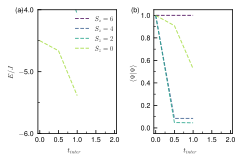

In [602]:
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size"  : 7
})

cm    = 1.0/2.54
width_col = 8.6*cm
width = width_col
height = width_col/3*2
plt.figure(figsize=(width,height),dpi=600)

cmap = plt.get_cmap('viridis')
colors = [cmap(isec / nsec) for isec in range(nsec)]

marker_style_1  = dict(marker='', linestyle='-', color='tab:red', alpha=0.4,  fillstyle='full')

marker_style_2  = dict(marker='', linestyle='-', color='mediumblue', alpha=0.4,  fillstyle='full')

marker_style_3  = dict(marker='', linestyle='-', color='green', alpha=0.5,  fillstyle='full')

marker_style_4  = dict(marker='', linestyle='-', color='black', alpha=0.5,  fillstyle='full')

marker_style_ref  = dict(marker='', linestyle='-', color='gray', alpha=0.5,  fillstyle='full')

axes = []

ax = plt.subplot2grid((1,2),(0,0))
axes.append(ax)
ax = plt.subplot2grid((1,2),(0,1))
axes.append(ax)

# (a) Energies

axis = axes[0]

y_min    = -6
y_max    = -4

x_min    =  -0.05
x_max    =  2.05

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.29,0.98,r'(a)',transform=axis.transAxes)
axis.set_xlabel(r'$t_{inter}$')
axis.set_ylabel(r'$E/J$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

axis.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

# plot
##axes[0].plot(t_exact_2x3, E_exact_2x3, label='', **marker_style_ref)
##axes[0].plot(t_2x3,E_2x3, label='', markersize=4, **marker_style_1)
for isec in range(0,nsec,2):
    color = colors[isec]
    axis.plot(t_inters,eigen_energies_exact[isec][:,0],
              label=fr'$S_z={Z_target[isec]//2}$', lw=1, marker='', linestyle='--',
              color=color, alpha=0.8)
#axis.axvline(x=1.0, label='', **marker_style_ref)


axis.legend(loc='upper right',frameon=False,bbox_to_anchor=(1.10, 1))


# (b) norms
axis = axes[1]

y_min    = -0.05
y_max    = 1.05

x_min    =  -0.05
x_max    =  2.05

axis.set_xlim(x_min,x_max)
axis.set_ylim(y_min,y_max)
# setup labels
axis.text(-0.29,0.98,r'(b)',transform=axis.transAxes)
axis.set_xlabel(r'$t_{inter}$')
axis.set_ylabel(r'$\langle\Psi|\Psi\rangle$')
# setup tics
axis.tick_params(axis='x', which='both', direction='in')
axis.tick_params(axis='y', which='both', direction='in')
axis.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axis.xaxis.set_major_formatter('{x:0.1f}')
axis.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))

axis.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axis.yaxis.set_major_formatter('{x:0.1f}')
axis.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
##axes[0].plot(t_exact_2x3, E_exact_2x3, label='', **marker_style_ref)
##axes[0].plot(t_2x3,E_2x3, label='', markersize=4, **marker_style_1)
for isec in range(0,nsec,2):
    color = colors[isec]
    axis.plot(t_inters,norms_exact[isec,:],
              label=fr'$S_z={Z_target[isec]//2}$', lw=1, marker='', linestyle='--',
              color=color,alpha=0.8)
#
#
#
#
#
#axis.legend(loc='lower left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()

plt.savefig('fig4.pdf')